# Eddy Flux

In [1]:
from smode_import import *

In [2]:
# load thermosalinograph data

TSG = xr.open_dataset('../S_MODE_IOP2_SRIDE23_tsg_met_bio.nc')
TSG = TSG.drop_duplicates(dim='time_bio')
TSG = TSG.drop_duplicates(dim='time')
flowrate_time_bio = TSG['flow_rate_lab_tsg'].interp(time=TSG['time_bio'], method='linear')
TSG['flowrate_time_bio'] = (TSG.chlorophyll_ACS.dims, flowrate_time_bio.values)
TSG

<xarray.Dataset> Size: 40MB
Dimensions:                              (time_bio: 32509, time: 147912,
                                          instrument: 1)
Coordinates:
  * time_bio                             (time_bio) datetime64[ns] 260kB 2023...
    latitude_bio                         (time_bio) float64 260kB ...
    longitude_bio                        (time_bio) float64 260kB ...
  * time                                 (time) datetime64[ns] 1MB 2023-04-07...
    latitude                             (time) float64 1MB ...
    longitude                            (time) float64 1MB ...
Dimensions without coordinates: instrument
Data variables: (12/47)
    TSG86                                (instrument) float64 8B ...
    TSG73                                (instrument) float64 8B ...
    SST62                                (instrument) float64 8B ...
    FLW19                                (instrument) float64 8B ...
    FLW20                                (instrument) float64 8B ...
    FLW09                                (instrument) float64 8B ...
    ...                                   ...
    beam_attenuation_657nm_ACS           (time_bio) float64 260kB ...
    chlorophyll_flourometer              (time_bio) float64 260kB ...
    particulate_organic_carbon_cstar     (time_bio) float64 260kB ...
    photosynthetically_active_radiation  (time_bio) float64 260kB ...
    CSTAR_QCflag                         (time_bio) float64 260kB ...
    flowrate_time_bio                    (time_bio) float64 260kB 2.844 ... 1...
Attributes: (12/52)
    DOI:                           10.5067/SMODE-RVTSG
    title:                         SMODE Shipboard bio-optical, meteorlogical...
    summary:                       Level-2 processed data from GPS, TSG and F...
    keywords:                      EARTH SCIENCE > OCEANS > OPTICS > ATTENUAT...
    keywords_vocabulary:           NASA Global Change Master Directory (GCMD)...
    conventions:                   CF-1.8, ACDD-1.3
    ...                            ...
    timetime_coverage_end:         2023-05-03T15:05:07Z
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  down
    date_created:                  2023-04-13T00:00:00Z
    time_coverage_duration:        P25D20H10M57S
    comment:                       See readme.txt. Thermosalinograph Data are...

## POC concentration composite

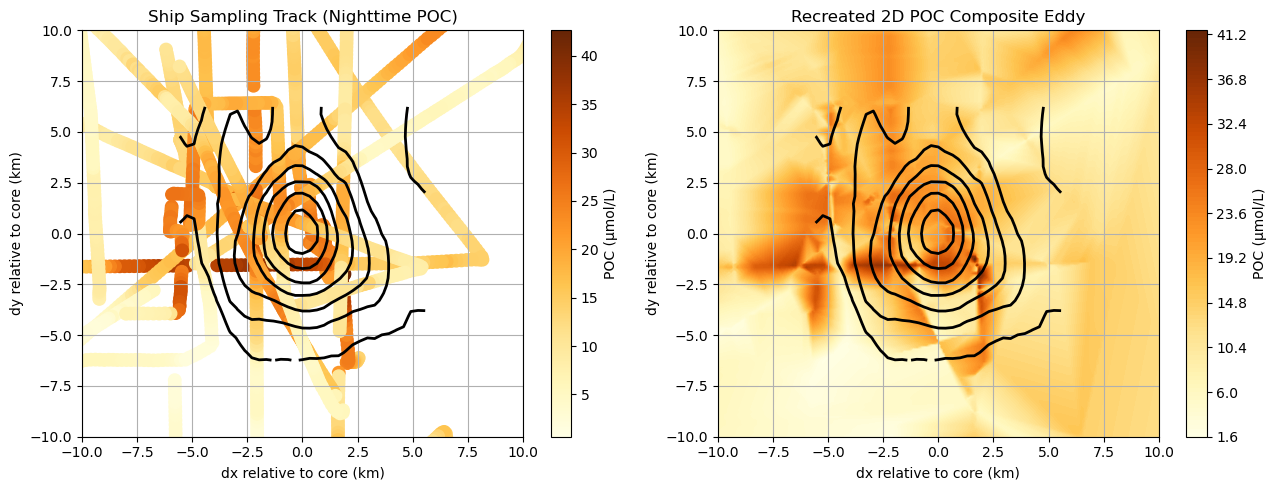

In [3]:
# POC composite

from scipy.interpolate import griddata
ds_interpolated = xr.open_dataset('../eddy_core_position.nc')

# get POC [μmol L-1] during the eddy time window
ACS_eddy_times = TSG['particulate_organic_carbon_acs'].sel(time_bio=slice('2023-04-18', '2023-04-23'))
upper_bound = 50  # Filter out outliers / biofouling spikes

# interpolate eddy core track onto ship sampling time
ds_interpolated_on_ACS = ds_interpolated.interp(time=ACS_eddy_times.time_bio, method='quadratic')

# calculate spatial offsets (dx, dy) in km relative to the eddy core
dlat = ds_interpolated_on_ACS.lat - ACS_eddy_times.latitude_bio
dlon = ds_interpolated_on_ACS.lon - ACS_eddy_times.longitude_bio

dy_km = dlat * 111320 / 1e3
dx_km = dlon * (111320 * np.cos(np.radians(ds_interpolated_on_ACS.lat.values))) / 1e3
dist_from_core = np.sqrt(dx_km**2 + dy_km**2)

# keep night-time values only to remove photochemical quenching
def is_night(timestamp, delta=-7):  # UTC to PST
    return (timestamp.dt.hour < 9 - delta) | (timestamp.dt.hour >= 17 - delta)

idx = (
    (~np.isnan(ACS_eddy_times)) & # remove nans
    (~np.isnan(dy_km)) &
    (~np.isnan(dx_km)) &
    (ACS_eddy_times < upper_bound) & # remove excessive values
    (is_night(ACS_eddy_times.time_bio)) # keep nighttime values
)

dx_km = dx_km[idx].values 
dy_km = dy_km[idx].values
poc_umol_L = ACS_eddy_times.values[idx]  # [μmol / L]

# POC 2D composite

# uniform 2D grid [-10, 10] km relative to eddy core
grid_resolution = 200 # [m]
dist_max = 10
x_line = np.linspace(-dist_max, dist_max, grid_resolution)
y_line = np.linspace(-dist_max, dist_max, grid_resolution)
x_2d, y_2d = np.meshgrid(x_line, y_line)

# interpolate ship track POC values onto the 2D grid
poc_2d = griddata((dx_km, dy_km), poc_umol_L, (x_2d, y_2d), method='linear')

# calculate distance from core for every pixel on the 2D grid [km]
dist_2d = np.sqrt(x_2d**2 + y_2d**2)

# plot
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# overlay vorticity contours
composite_eddy = xr.open_dataset('../composite_eddy_centered.nc')
for axis in ax:
    composite_eddy.vor_eddy.plot.contour(levels=np.linspace(-2,2,16),colors='k',linewidths=2,ax=axis,zorder=101)

# Left: individual points along ship track
p0 = ax[0].scatter(dx_km, dy_km, c=poc_umol_L, s=80, cmap='YlOrBr')
ax[0].set_title("Ship Sampling Track (Nighttime POC)")
ax[0].set_xlabel("dx relative to core (km)")
ax[0].set_ylabel("dy relative to core (km)")
ax[0].set_xlim(-dist_max, dist_max)
ax[0].set_ylim(-dist_max, dist_max)
ax[0].grid(True)
plt.colorbar(p0, ax=ax[0], label="POC (μmol/L)")

# Right: interpolated 2D POC composite
p1 = ax[1].contourf(x_2d, y_2d, poc_2d, levels=100, cmap='YlOrBr')
ax[1].set_title("Recreated 2D POC Composite Eddy")
ax[1].set_xlabel("dx relative to core (km)")
ax[1].set_ylabel("dy relative to core (km)")
ax[1].set_xlim(-dist_max, dist_max)
ax[1].set_ylim(-dist_max, dist_max)
ax[1].grid(True)
plt.colorbar(p1, ax=ax[1], label="POC (μmol/L)")

plt.tight_layout()
plt.show()

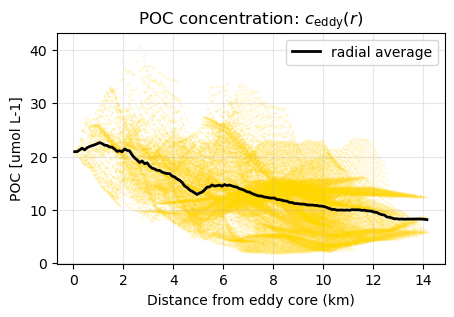

In [4]:
# POC as a function from dist_from_core (from 0 to 10 km)

dist_radial = np.sqrt(x_2d**2 + y_2d**2)

bin_width = 0.1 # [km]
r_bins = np.arange(0, np.max(dist_radial) + bin_width, bin_width)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2.0 # for plotting

# initialize
poc_radial_mean = np.zeros(len(r_centers))
poc_radial_std = np.zeros(len(r_centers))

for i in range(len(r_centers)):
    bin_mask = (dist_2d >= r_bins[i]) & (dist_2d < r_bins[i+1]) & (~np.isnan(poc_2d))
    
    if np.any(bin_mask):
        poc_radial_mean[i] = np.mean(poc_2d[bin_mask])
        poc_radial_std[i] = np.std(poc_2d[bin_mask])
    else:
        poc_radial_mean[i] = np.nan
        poc_radial_std[i] = np.nan

# plot
plt.figure(figsize=(5,3))
plt.scatter(dist_radial, poc_2d.flatten(), s=1, c='gold', alpha=0.1)
plt.plot(r_centers, poc_radial_mean, c='k', lw=2, label='radial average')

plt.legend()
plt.grid(alpha=0.3)
plt.xlabel('Distance from eddy core (km)')
plt.ylabel('POC [umol L-1]')
plt.title(r'POC concentration: $c_{\text{eddy}}(r)$')
plt.show();

## Submesoscale Eddy POC Inventory

To total POC inventory of our submesoscale eddy is:
$$
M_{\text{eddy}} = MLD \times 2\pi \int_{0}^{R_{\text{eddy}}} c_{\text{eddy}}(r)~rdr
$$

where $c_{\text{eddy}}$ is the measured POC concentration averaged from TSG, $R_{\text{eddy}}$ is the eddy's radius ($5~km$), MLD is the mixed-layer depth ($25~m$).

Note that any variable with subscript $_{\text{eddy}}$ refers to our own submesoscale eddy.

In [5]:
from scipy.integrate import trapezoid

# parameters
MW_C = 12.011   # Molecular weight of carbon (mg/mmol or g/mol)
MLD = 25      # Mixed-layer depth (m)
R_eddy = 5000 # Eddy radius (m)

# keep data within 5 km
r_m = r_centers * 1000.0 # km to m
mask = ~np.isnan(poc_radial_mean) & ~np.isnan(poc_radial_std) & (r_m <= R_eddy)

r_valid = r_m[mask]
poc_mean_valid = poc_radial_mean[mask] # mmol m-3
poc_std_valid = poc_radial_std[mask]   # mmol m-3

# integral
poc_integration_mean = trapezoid(poc_mean_valid * r_valid, x=r_valid) # mmol m-1
M_eddy_mmol = MLD * 2*np.pi * poc_integration_mean # [mmol C]

# conversion mol to grams
M_eddy_g = M_eddy_mmol * MW_C / 1000.0   # [g C]
M_eddy_Gg = M_eddy_mmol * MW_C/ 1e12 # [Gg C]

# std propagation (trapezoidal rule)
weights = np.gradient(r_valid)
std_integration = np.sqrt(np.sum((weights * r_valid * poc_std_valid)**2))

M_eddy_std_mmol = MLD * 2*np.pi * std_integration # [mmol C]
M_eddy_std_Gg = (M_eddy_std_mmol * MW_C) / 1e12       # [Gg C]

# volumetric concentration (we divide by eddy volume)
V_eddy = np.pi * (R_eddy**2) * MLD # m^3
C_bar_eddy = M_eddy_mmol / V_eddy  # [mmol m^-3]
C_bar_eddy_std = M_eddy_std_mmol / V_eddy  # [mmol m^-3]

#print(f"Total POC Inventory: {C_eddy_mmol:.2e} +/- {C_eddy_std_mmol:.2e} mmol C")
print(f"Eddy POC Inventory: {M_eddy_Gg:.4f} ± {M_eddy_std_Gg:.4f} Gg C")
print(f"Eddy POC Concentration: {C_bar_eddy:.2f} ± {C_bar_eddy_std:.2f} mmol m-3")

Eddy POC Inventory: 0.4051 ± 0.0192 Gg C
Eddy POC Concentration: 17.18 ± 0.81 mmol m-3


## POC Eddy Export Flux

The lateral eddy export flux of POC is given by:
$$
F' = u_{\text{eddy}} \times \bar{C}' \times \hat{f}
$$

* $u_{\text{eddy}}$ is the zonal velocity inferred from our submesoscale eddy position from Dopplerscatt observations
* $C'$ is the POC concentration anomaly ($\text{mmol m}^{-3}$) relative to the ambient background using satellite imagery of surface POC
* $\hat{f}$ is spatial fraction ($0 \le \hat{f} \le 1$) of eddy occupation along the cloud-free 124$\degree$W line, from 33 to 39$\degree$N


### Zonal Velocity (u_eddy)
We assume our eddy's u is average, not in paper's limitations

In [6]:
u_eddy = 0.05 # m s-1

### Eddy POC Concentration $(\bar{C}')$

#### Find the exact coordinates of the submesoscale eddies crossing the 124W line

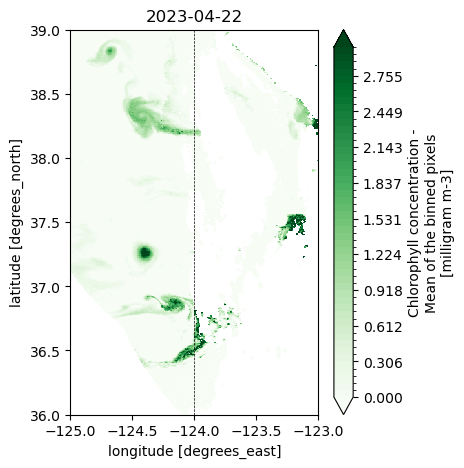

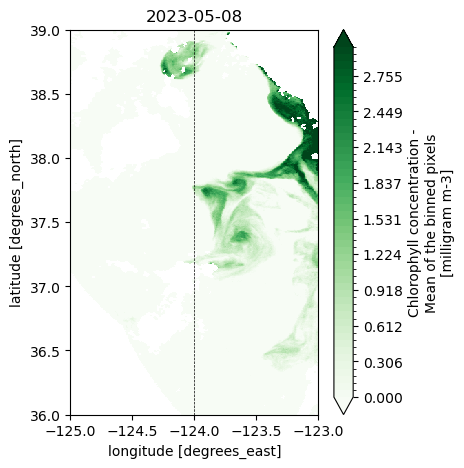

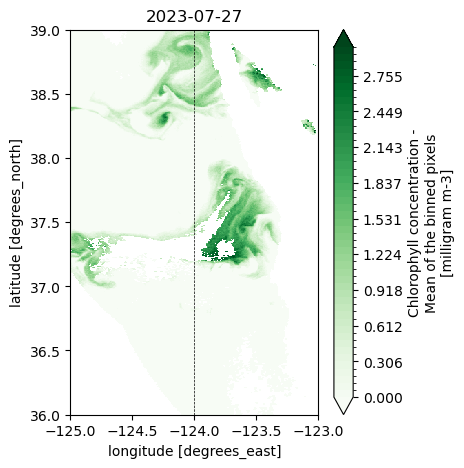

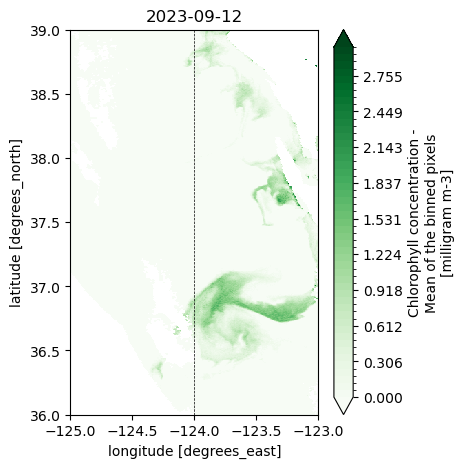

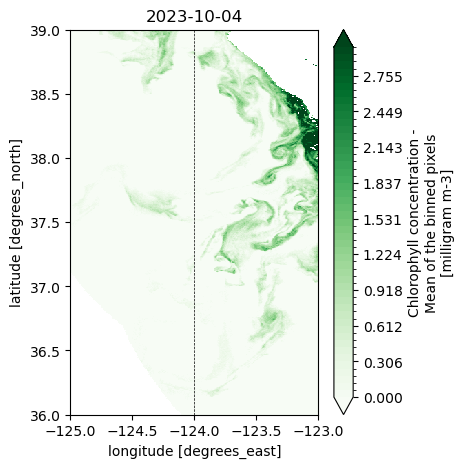

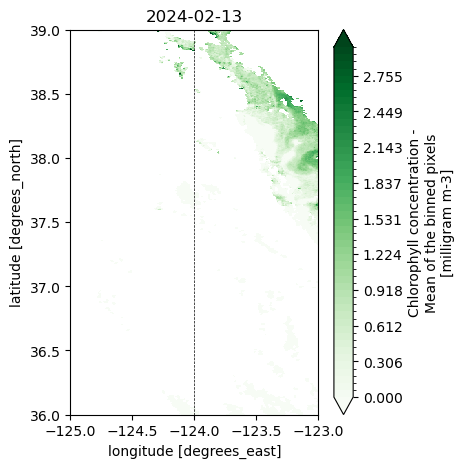

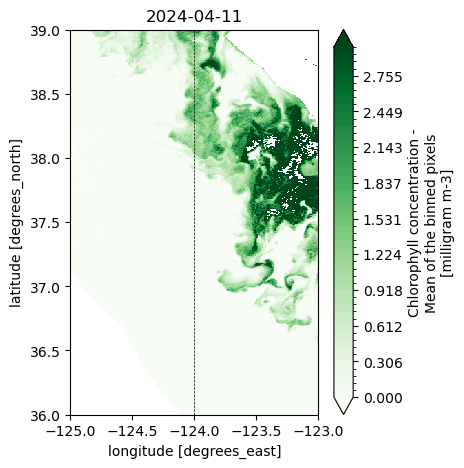

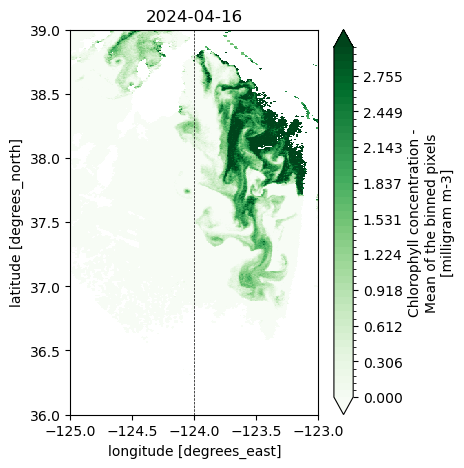

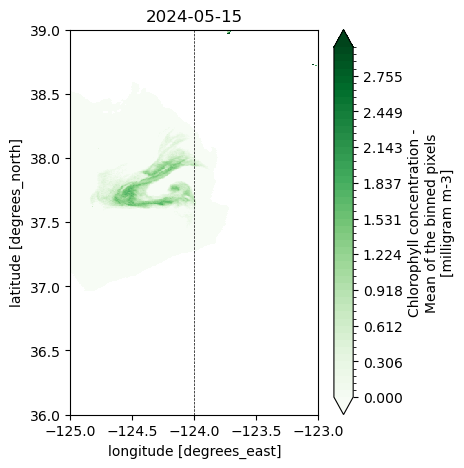

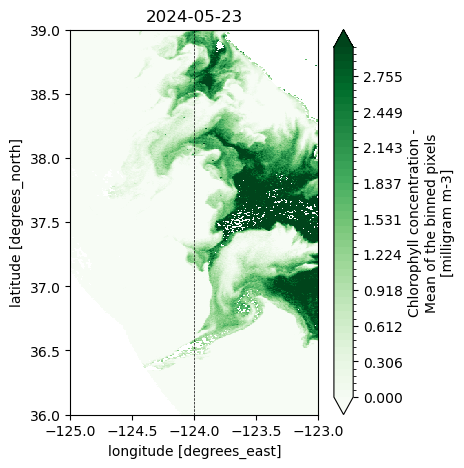

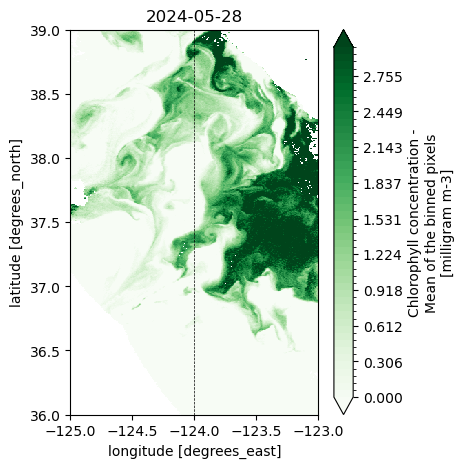

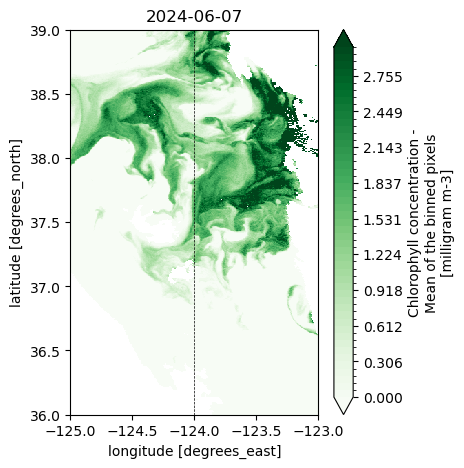

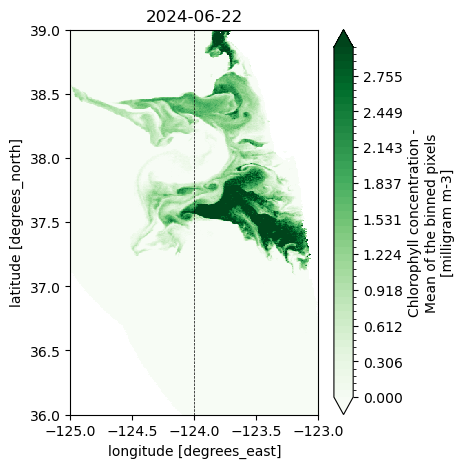

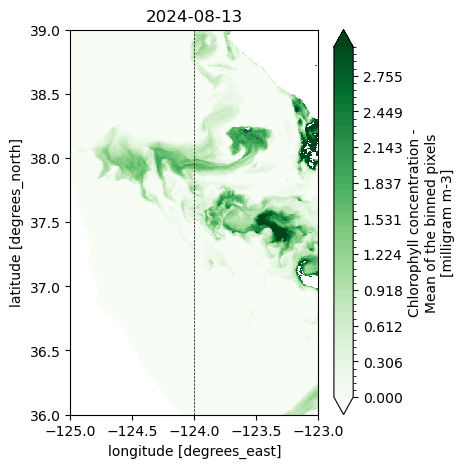

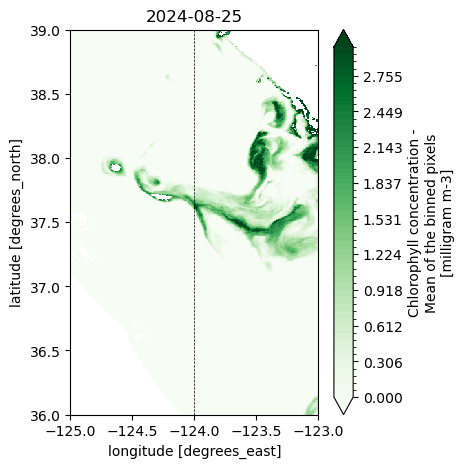

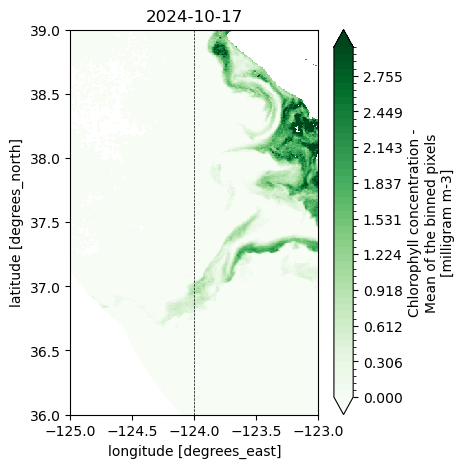

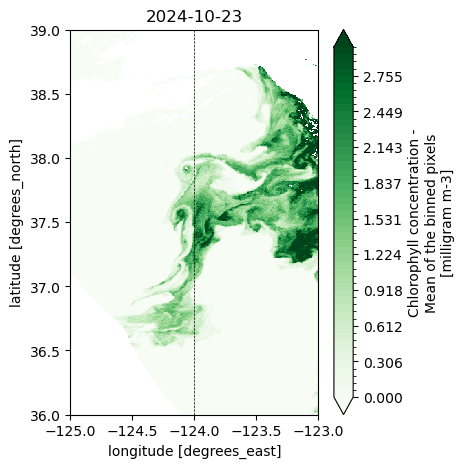

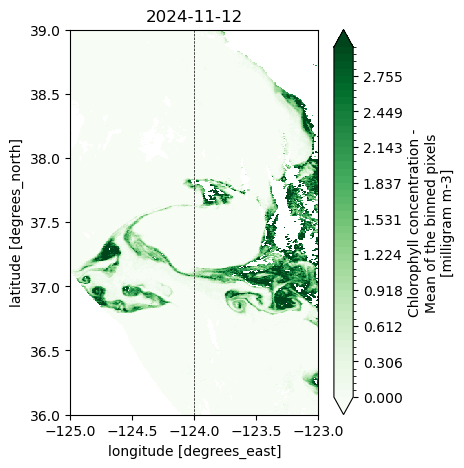

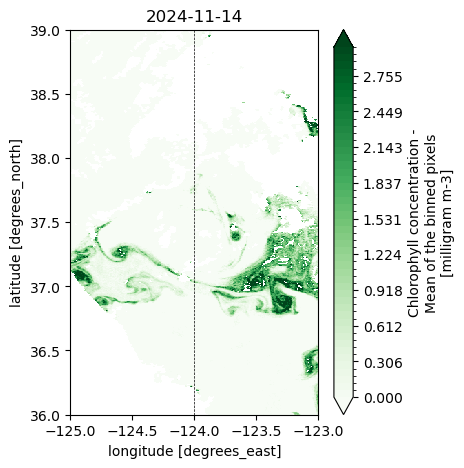

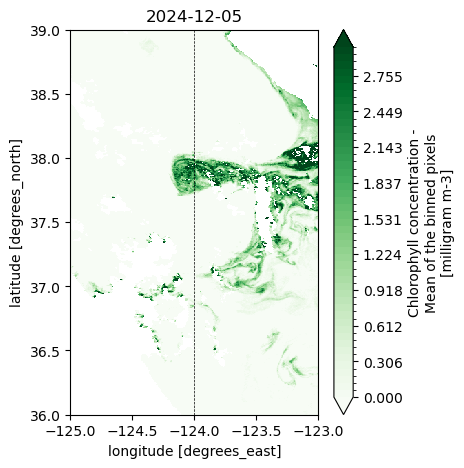

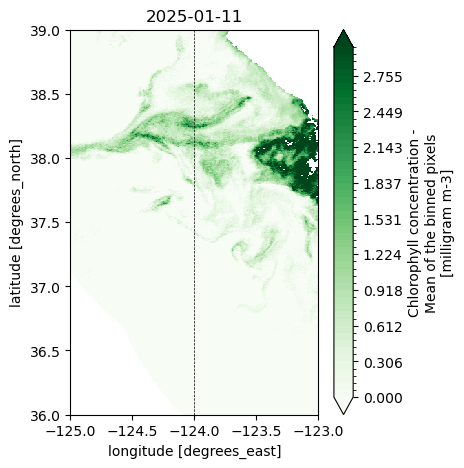

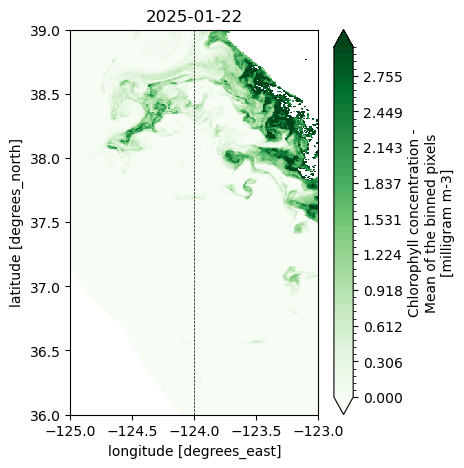

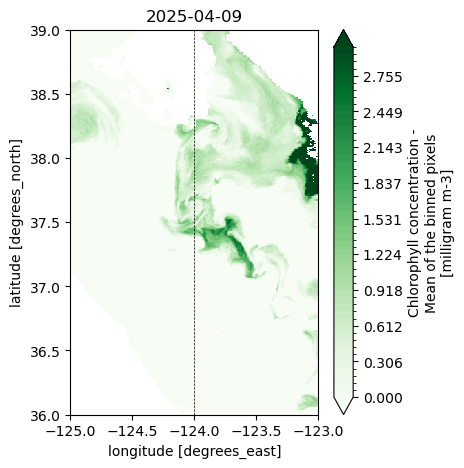

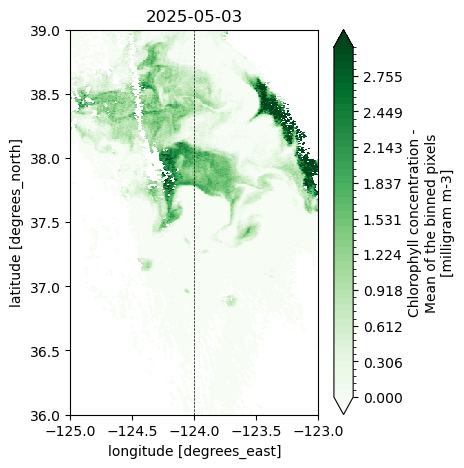

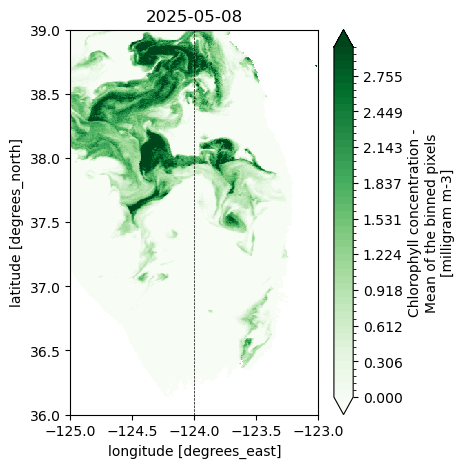

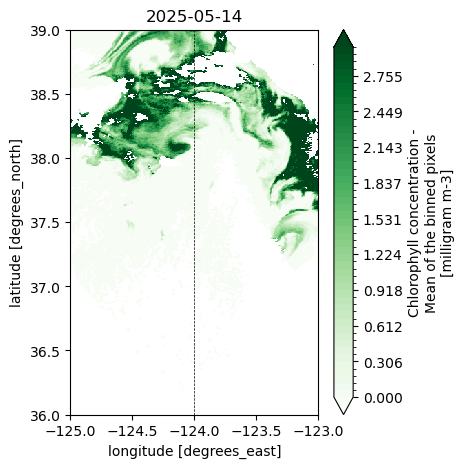

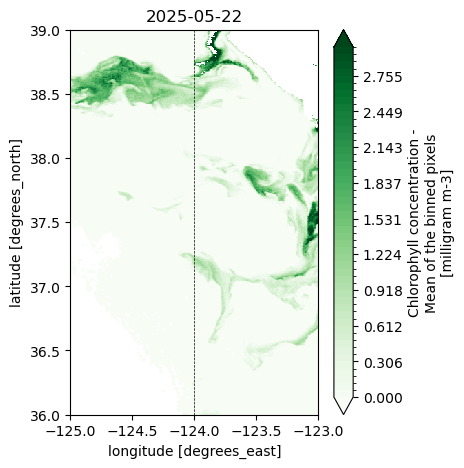

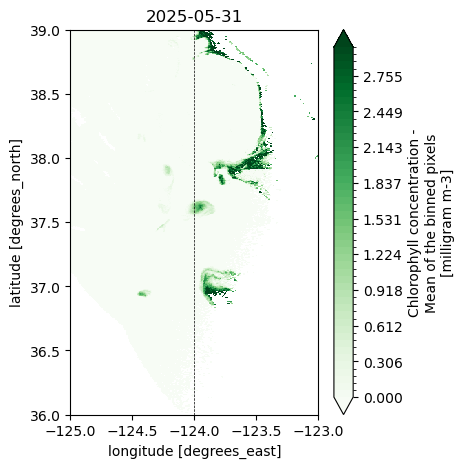

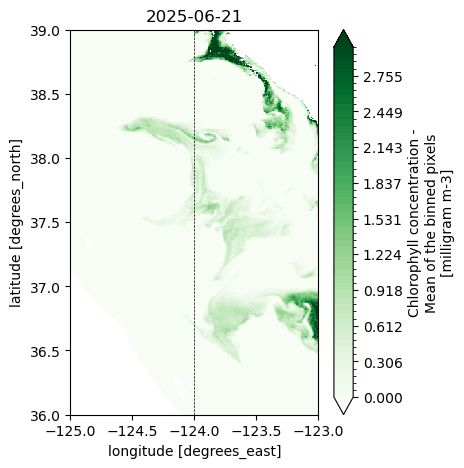

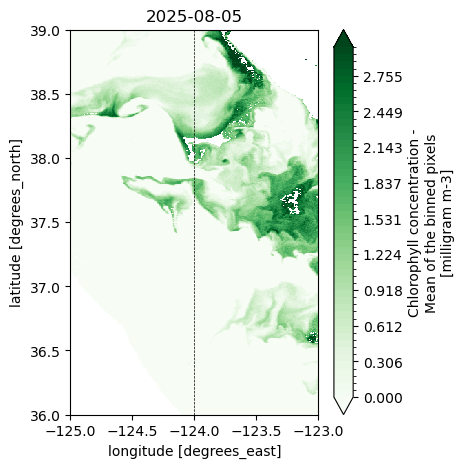

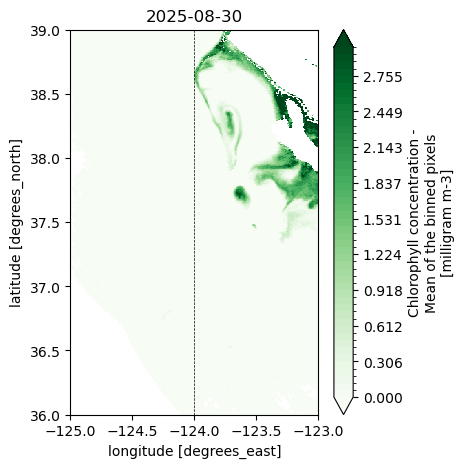

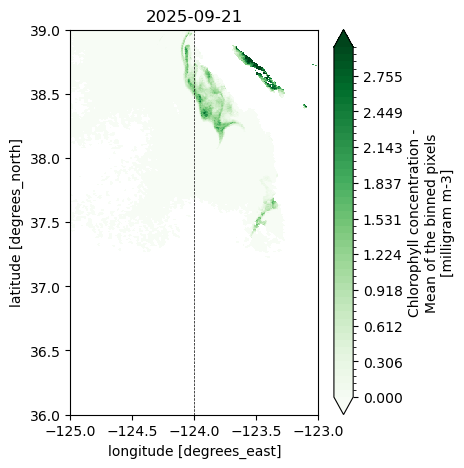

In [7]:
from glob import glob
MW_C = 12.011

OLCI_files = sorted(glob('../olci_300m_downloads/*'))

for file in OLCI_files:
    chl_300m = xr.open_dataset(file)['CHL']

    chl_300m_log = np.log(chl_300m)

    # Loisel et al. / Stramski et al. conversion algorithm
    poc_mg_m3 = 308.28 * (chl_300m ** 0.56) # to POC mass concentration [mg/m3]
    poc_mmol_m3 = poc_mg_m3 / MW_C # to molar concentration [mmol C / m3]

    time_str = str(chl_300m.time.values)[2:12]

    fig, ax = plt.subplots(1,1,figsize=(4,5))

    chl_300m_log.plot(levels=np.linspace(0,3,50), extend='both', ax=ax, cmap='Greens') # log chl
    #poc_mg_m3.plot(ax=ax[1], cmap='Oranges') # mass concentration
    #poc_mmol_m3.plot(ax=ax[1], cmap='YlOrBr',vmin=0,vmax=400,cbar_kwargs={'label': r'POC [mmol C m$^{-3}$]'}) # mol concentration
    #for axis in ax:
    ax.axvline(-124,color='k',linestyle='--',lw=0.5)
    ax.set_title(time_str)
    
    plt.xlim(-125, -123)
    plt.ylim(36,39)
    plt.show();
    

#C_bar_prime = 

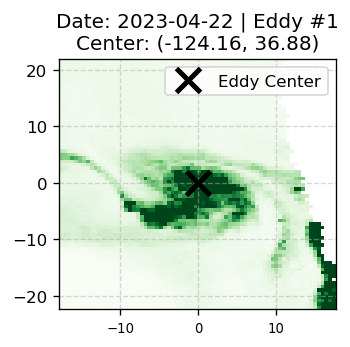

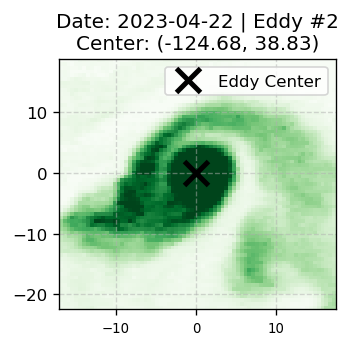

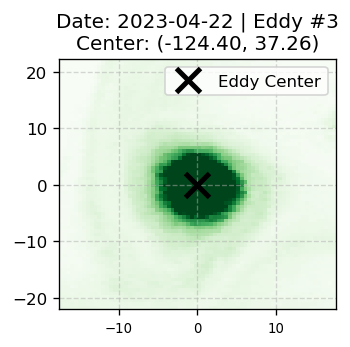

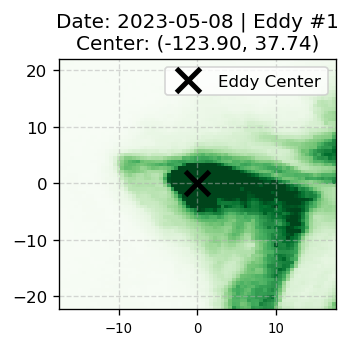

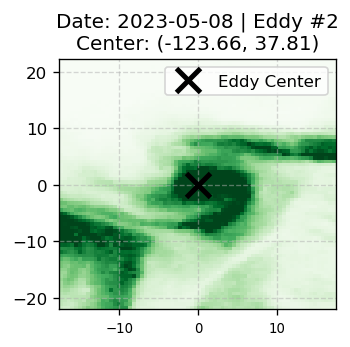

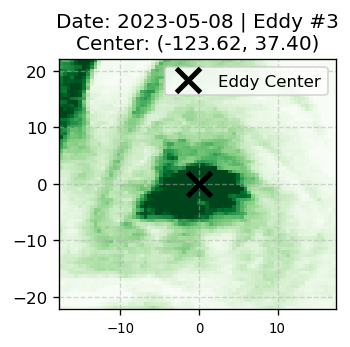

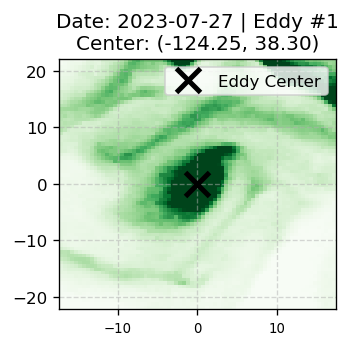

No coordinates listed for 2023-09-12, skipping...


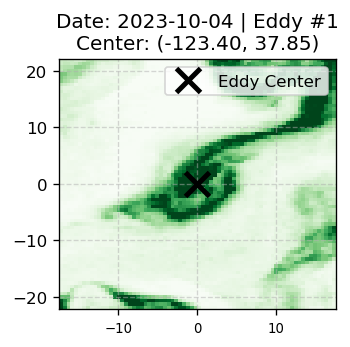

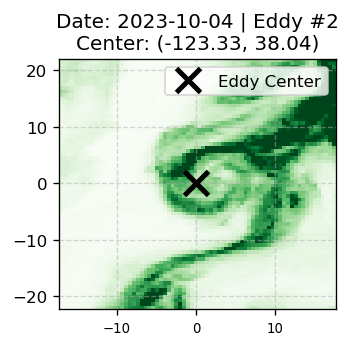

No coordinates listed for 2024-02-13, skipping...
No coordinates listed for 2024-04-11, skipping...


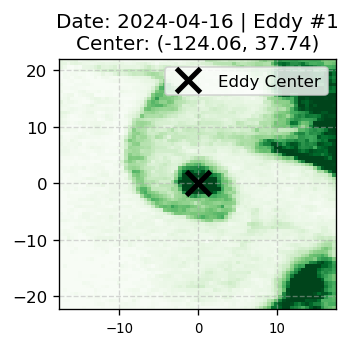

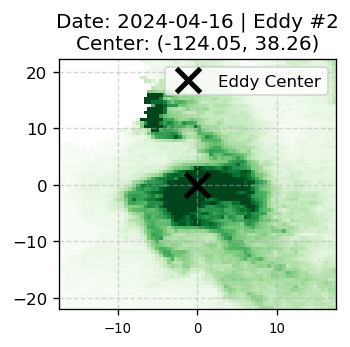

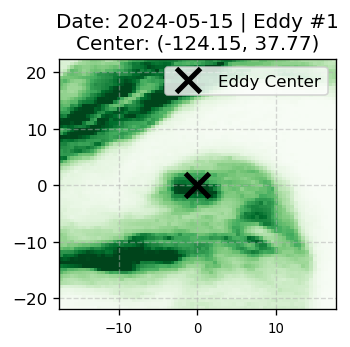

No coordinates listed for 2024-05-23, skipping...


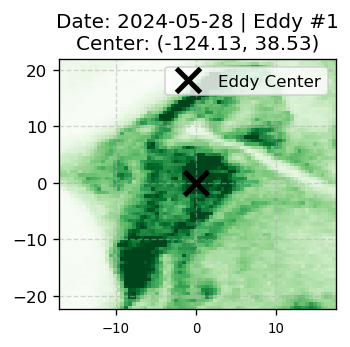

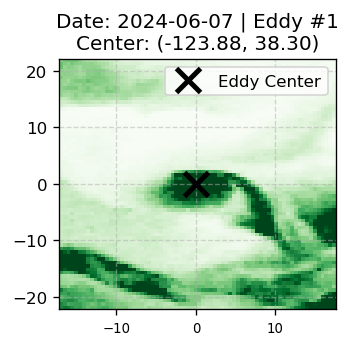

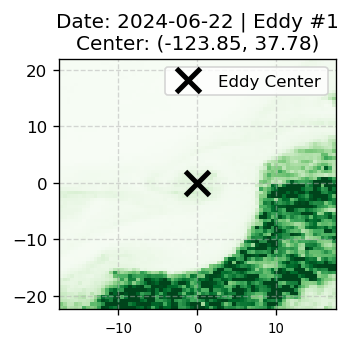

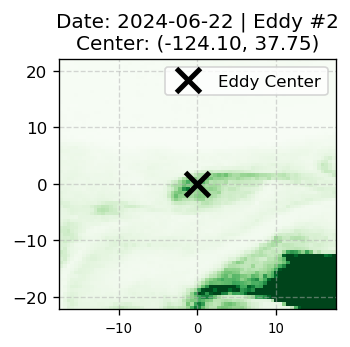

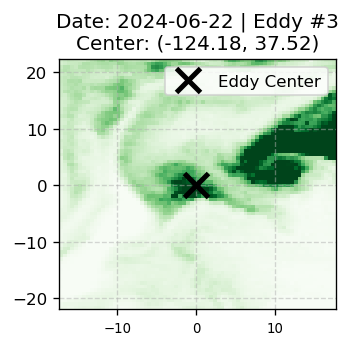

No coordinates listed for 2024-08-13, skipping...


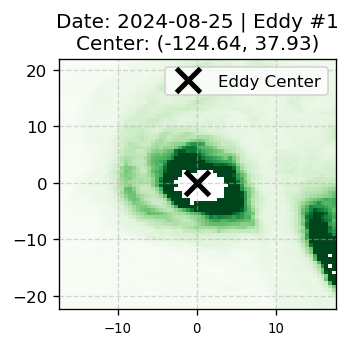

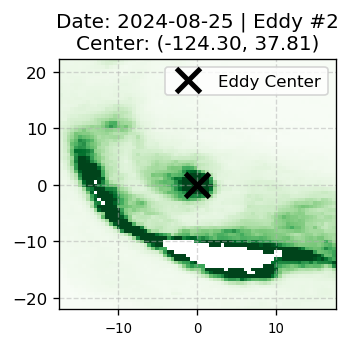

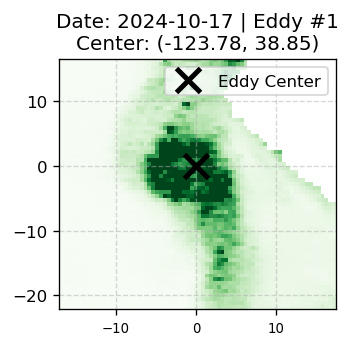

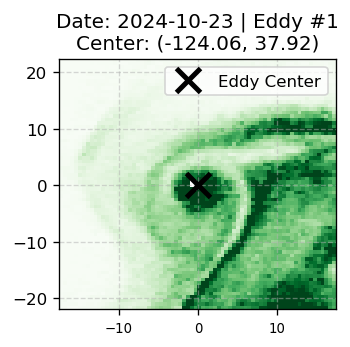

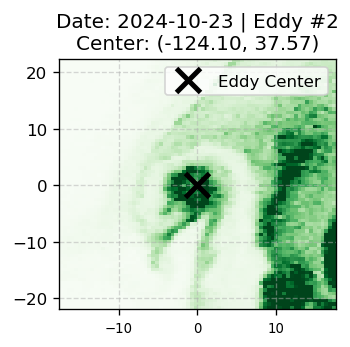

No coordinates listed for 2024-11-12, skipping...


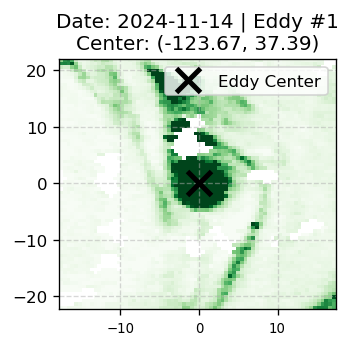

No coordinates listed for 2024-12-05, skipping...


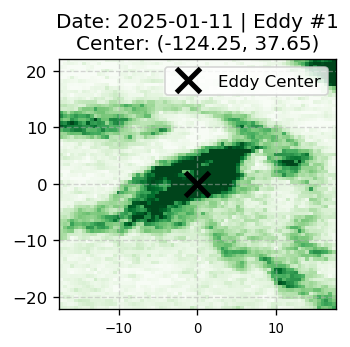

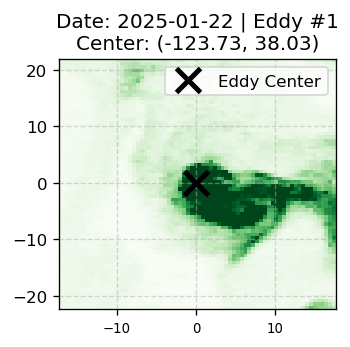

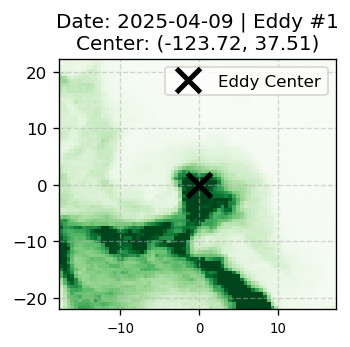

No coordinates listed for 2025-05-03, skipping...


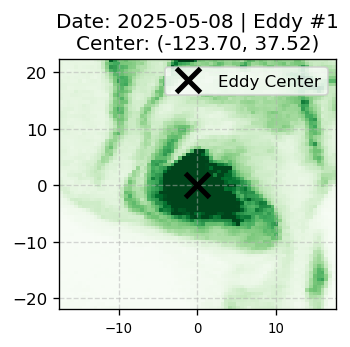

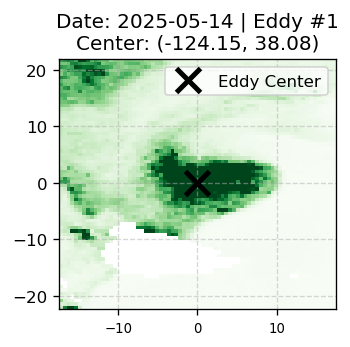

No coordinates listed for 2025-05-22, skipping...


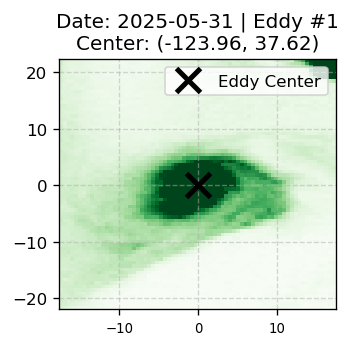

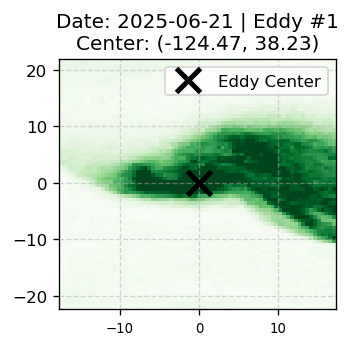

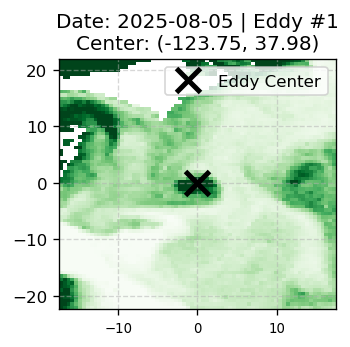

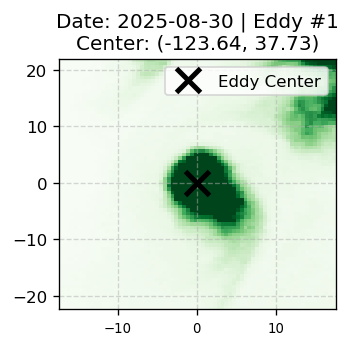

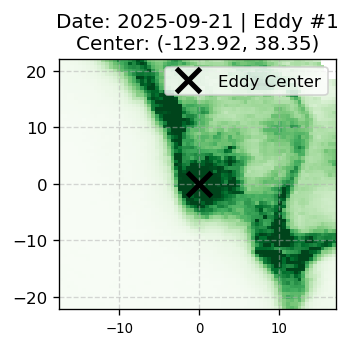

In [8]:
# We verify they lat/lon coordinates by zooming in on each individual submesoscale eddy
import ast
import os

# load excel sheet
excel_path = "../count-submesoscale-eddies.xlsx"
df = pd.read_excel(excel_path)
df.columns = ['Date', 'Count', 'Coord1', 'Coord2', 'Coord3'] + list(df.columns[5:])

# helper to parse "(Lon,Lat)"
def parse_coord(coord_str):
    if pd.isna(coord_str) or not isinstance(coord_str, str):
        return None
    try:
        lon, lat = ast.literal_eval(coord_str.strip())
        return float(lon), float(lat)
    except:
        return None # this is for empty coords

olci_dir = "../olci_300m_downloads"

# loop through each submesoscale eddy
for idx, row in df.iterrows():
    # convert date string to YYYY-MM-DD to find file
    date_dt = pd.to_datetime(row['Date'])
    try:
        date_str = date_dt.strftime('%Y-%m-%d')
    except:
        continue
    nc_file = os.path.join(olci_dir, f"OLCI_300m_CHL_{date_str}.nc")
        
    # get (Lon,Lat)
    coords = [parse_coord(row['Coord1']), parse_coord(row['Coord2']), parse_coord(row['Coord3'])]
    coords = [c for c in coords if c is not None]
    
    if not coords:
        print(f"No coordinates listed for {date_str}, skipping...")
        continue
        
    # Open NetCDF dataset
    ds = xr.open_dataset(nc_file)
    chl = ds['CHL']
    
    # Plot each coordinate individually
    for ed_idx, (lon_center, lat_center) in enumerate(coords, 1):
        # Slice +/- 0.5 degrees around center
        delta = 0.2
        chl_crop = chl.sel(
            latitude=slice(lat_center - delta, lat_center + delta),
            longitude=slice(lon_center - delta, lon_center + delta)
        )

        # Extract 2D coordinate arrays
        lons = chl_crop.longitude.values
        lats = chl_crop.latitude.values
        
        # Convert lat/lon grid into relative kilometer offsets dx, dy from center (0,0)
        dy = (lats - lat_center) * 111.0  # km north/south
        dx = (lons - lon_center) * 111.0 * np.cos(np.radians(lat_center))  # km east/west

        plot_type = 'relative' # 'latlon'

        # === PLOT SECTION ===
        fig, ax = plt.subplots(figsize=(3, 3), dpi=120)

        # plot OLCI chl
        if plot_type=='relative':
            # plot in relative kilometer space (dx, dy)
            mesh = ax.pcolormesh(dx, dy, np.squeeze(chl_crop.values), cmap='Greens', shading='nearest',
                                 vmin=np.nanpercentile(chl_crop.values, 5),
                                 vmax=np.nanpercentile(chl_crop.values, 95)
            )

            # draw "X" at (0,0)
            ax.plot(0, 0, 'kx', markersize=14, markeredgewidth=3, label='Eddy Center')
            
        elif plot_type=='latlon':
            p = chl_crop.plot(ax=ax, cmap='Greens', robust=True, cbar_kwargs={'label': r'Chlorophyll-a [mg m$^{-3}$]'})
        
            # draw "X" on eddy center
            ax.plot(lon_center, lat_center, 'kx', markersize=14, markeredgewidth=3, label='Eddy Center')
        
        ax.set_title(f"Date: {date_str} | Eddy #{ed_idx}\nCenter: ({lon_center:.2f}, {lat_center:.2f})")
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right')
        ax.set_xlabel('')
        ax.set_ylabel('')
        plt.xticks(fontsize=8)
        plt.tight_layout()
        plt.show()
        
    ds.close()

#### Submesoscale eddy stats
For each submesoscale eddy identified form OLCI satellite imagery (from Chl), we follow these steps:

**1. Convert chl to POC**

We use Stramski et al. 2008 to convert satellite Chl to POC values:
$$
POC = \frac{308.28 \times [chl]^{0.56}}{12.011}
$$

*Function: `chl_to_poc_mmol(chl_dataarray, mw_c=12.011)`*


**2. Detect eddy radius**

The eddy radius is estimated when the averaged POC concentration around a concentric ring around the eddy core is 30% of the backgroup POC value. This might sound arbitrary, but it works well for first-order to automatically detect eddy radius.

*Function: `detect_eddy_radius_threshold(poc_values, dist_km, max_r_km=12.0, threshold_pct=0.30, step_km=0.5)`*

**3. Compute POC inventory**

Total POC mass [Gg C] within the eddy is calculated following:

$$
POC_{\text{inventory}} = MLD * 2*pi \int_0^{R_\text{eddy}} c(r) r dr
$$

*Function: `compute_poc_inventory(radii_centers, ring_poc_means, detected_r_km, mld_m=25)`*


**4. Extract background POC concentration**
Background POC concentration is computed along the 36-39$\degree$N line from the position of the eddy, masking out the eddy itself.

*Function: `compute_line_background_at_eddy_lon(ds, lon_center, lat_center, radius_km, lat_min=36.0, lat_max=39.0)`*

**5. Plot eddy**
Plots a zoom in of the eddy with POC concentration as colors, overlaid with a marker X at its core, and a thick blue line for the detected radius. Can be shown either in "relative" coordinates with (0,0) at the eddy core, or in lat/lon coordinates.

*Function: `plot_eddy_crop(poc_crop, dx, dy, lon_center, lat_center, date_str, ed_idx,detected_r_km, mean_core_poc,plot_type='relative')`



In [49]:
# all functions here

import ast
import os

def parse_coord(coord_str):
    """Safely converts a string '(Lon,Lat)' into a tuple of floats."""
    if pd.isna(coord_str) or not isinstance(coord_str, str):
        return None
    try:
        lon, lat = ast.literal_eval(coord_str.strip())
        # Enforce negative sign for West longitudes if missing
        if lon > 0:
            lon = -lon
        return float(lon), float(lat)
    except:
        return None

def chl_to_poc_mmol(chl_dataarray, mw_c=12.011):
    poc_mg_m3 = 308.28 * (chl_dataarray ** 0.56)
    return poc_mg_m3 / mw_c

import numpy as np

def detect_eddy_radius_threshold(poc_values, dist_km, max_r_km=12.0, threshold_pct=0.10, step_km=0.5):
    # 1. Compute Core and Background POC
    bg_mask = (dist_km >= 10.0) & (dist_km <= 15.0)
    c_bg = np.nanmedian(poc_values[bg_mask]) if np.any(bg_mask) else np.nanpercentile(poc_values, 10)
    
    c_peak = np.nanmean(poc_values[dist_km <= 1.0])
    if np.isnan(c_peak) or c_peak <= c_bg:
        c_peak = np.nanmax(poc_values[dist_km <= 3.0])
        
    # Cutoff threshold: Background + 30% of the peak elevation above background
    c_cutoff = c_bg + threshold_pct * (c_peak - c_bg)
    
    # 2. Concentric Rings Averages
    bins = np.arange(0, max_r_km + step_km, step_km)
    ring_centers = (bins[:-1] + bins[1:]) / 2.0
    
    bin_indices = np.digitize(dist_km, bins) - 1
    ring_poc_means = np.array([
        np.nanmean(poc_values[bin_indices == i]) if np.any(bin_indices == i) else np.nan
        for i in range(len(ring_centers))
    ])
    
    # 3. Find First Ring (past core) where concentration hits threshold
    valid_mask = (ring_centers > 1.5) & (~np.isnan(ring_poc_means))
    below_cutoff = valid_mask & (ring_poc_means <= c_cutoff)
    
    if np.any(below_cutoff):
        detected_r_km = ring_centers[np.argmax(below_cutoff)]
    else:
        detected_r_km = max_r_km

    # 4. Compute Volumetric Core Mean
    mean_core_poc = np.nanmean(poc_values[dist_km <= detected_r_km])
    
    return detected_r_km, mean_core_poc, ring_centers, ring_poc_means
    
def compute_poc_inventory(radii_centers, ring_poc_means, detected_r_km, mld_m=25.0):
    mask = radii_centers <= detected_r_km
    r_vals = radii_centers[mask]          # km
    c_vals = ring_poc_means[mask]         # mmol C / m3
    
    if len(r_vals) < 2:
        return 0.0
        
    r_m = r_vals * 1000.0                 # km to m
    integrand = c_vals * r_m              # [mmol C / m2]
    
    # Numerical Integration using Trapezoidal Rule
    integral_val = np.trapz(integrand, r_m)               # [mmol C / m]
    total_mmol_c = mld_m * 2.0 * np.pi * integral_val     # [mmol C]
    
    # Convert mmol C -> Grams -> Gigagrams (Gg C)
    total_g_c = (total_mmol_c * 12.011) / 1000.0         # [g C]
    inventory_GgC = total_g_c / 1e9                       # [Gg C]
    
    return float(inventory_GgC)


def compute_line_background_at_eddy_lon(ds, lon_center, lat_center, radius_km, lat_min=36.0, lat_max=39.0):
    try:
        lon_name = 'longitude' if 'longitude' in ds.dims or 'longitude' in ds.coords else 'lon'
        lat_name = 'latitude' if 'latitude' in ds.dims or 'latitude' in ds.coords else 'lat'
        
        line_slice = ds['CHL'].sel({lon_name: lon_center}, method='nearest').sel({lat_name: slice(lat_min, lat_max)})
        poc_line = chl_to_poc_mmol(line_slice)
        
        lats = line_slice[lat_name].values
        poc_vals = np.squeeze(poc_line.values)
        
        radius_deg = radius_km / 111.0
        eddy_lat_mask = (lats >= (lat_center - radius_deg)) & (lats <= (lat_center + radius_deg))
        background_mask = ~eddy_lat_mask & ~np.isnan(poc_vals)
        
        if np.sum(background_mask) == 0:
            return float(np.nanmedian(poc_vals))
            
        return float(np.nanmedian(poc_vals[background_mask]))
    except Exception:
        return np.nan


def plot_eddy_crop(poc_crop, dx, dy, lon_center, lat_center, date_str, ed_idx, 
                    detected_r_km, mean_core_poc, plot_type='relative'):
    fig, ax = plt.subplots(figsize=(4, 4), dpi=120)
    poc_vals = np.squeeze(poc_crop.values)
    
    if plot_type == 'relative':
        mesh = ax.pcolormesh(
            dx, dy, poc_vals, cmap='YlOrRd', shading='nearest',
            vmin=np.nanpercentile(poc_vals, 5),
            vmax=np.nanpercentile(poc_vals, 95)
        )
        cbar = plt.colorbar(mesh, ax=ax, shrink=0.8)
        cbar.set_label(r'POC [mmol C m$^{-3}$]', fontsize=8)
        
        ax.plot(0, 0, 'kx', markersize=10, markeredgewidth=2, label='Center (0,0)')
        cutoff_circle = plt.Circle((0, 0), detected_r_km, color='blue', fill=False, 
                                   linewidth=2, label=f'Radius ({detected_r_km} km)')
        ax.add_patch(cutoff_circle)
        
        ax.set_xlim(-15, 15)
        ax.set_ylim(-15, 15)
        ax.set_aspect('equal')
        
    elif plot_type == 'latlon':
        poc_crop.plot(ax=ax, cmap='YlOrRd', robust=True, cbar_kwargs={'label': r'POC [mmol C m$^{-3}$]'})
        ax.plot(lon_center, lat_center, 'kx', markersize=10, markeredgewidth=2, label='Center')

    ax.set_title(f"Date: {date_str} | Eddy #{ed_idx}\nR = {detected_r_km} km | POC = {mean_core_poc:.2f} mmol/m³", fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=7)
    plt.tight_layout()
    plt.show()

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


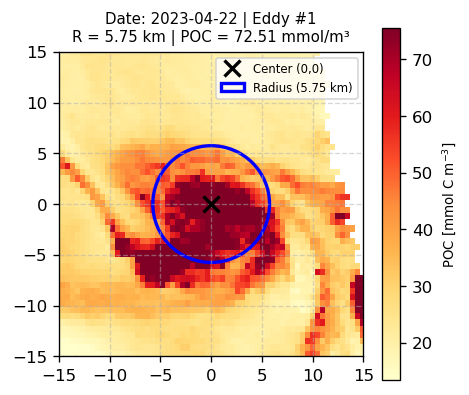

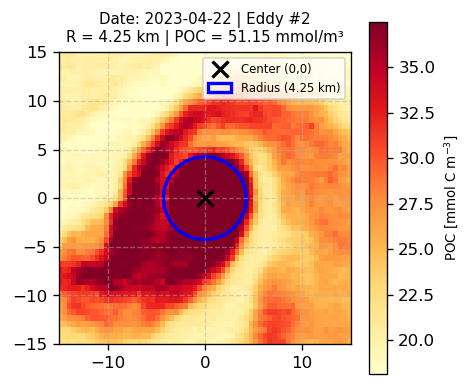

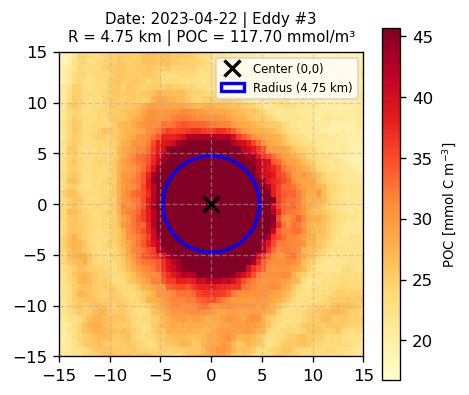

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


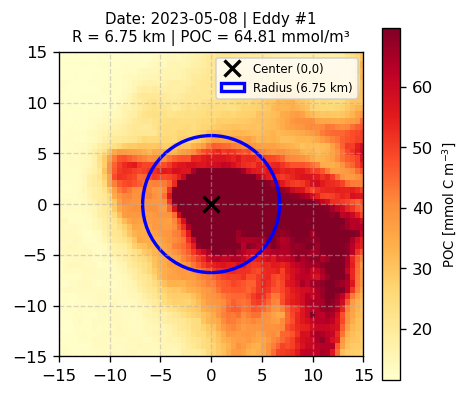

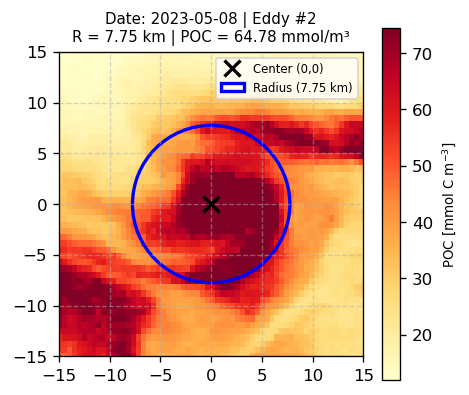

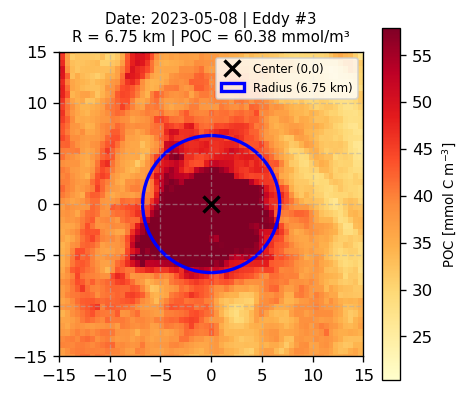

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


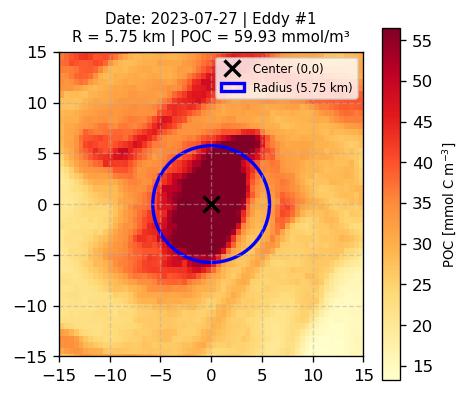

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


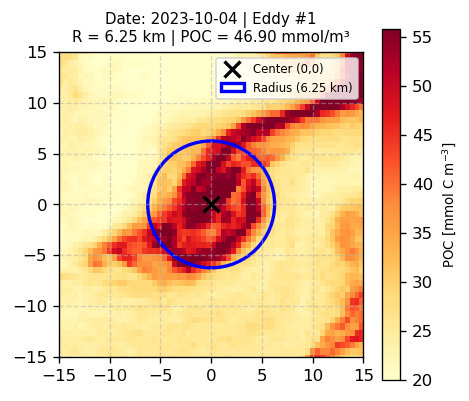

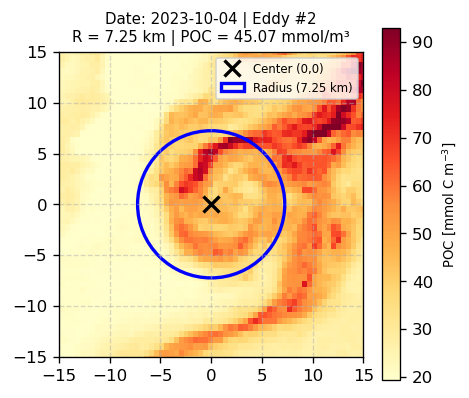

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


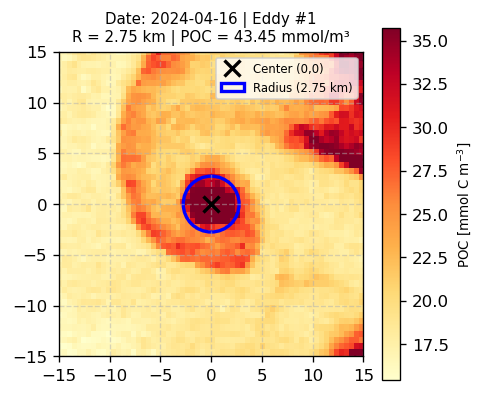

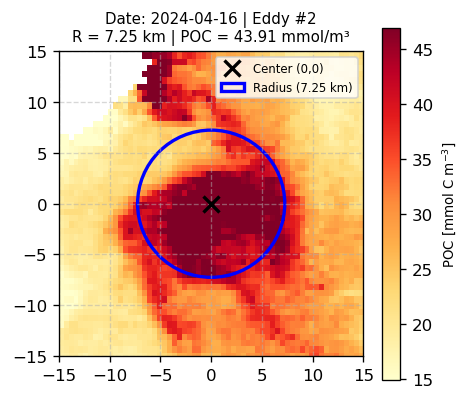

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


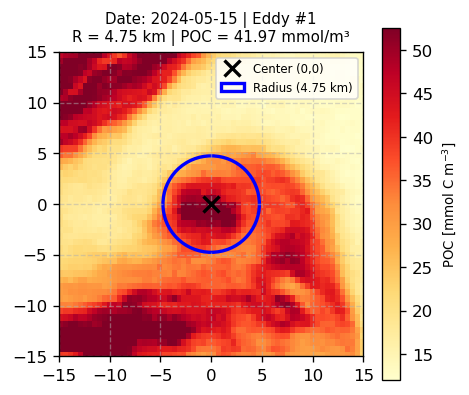

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


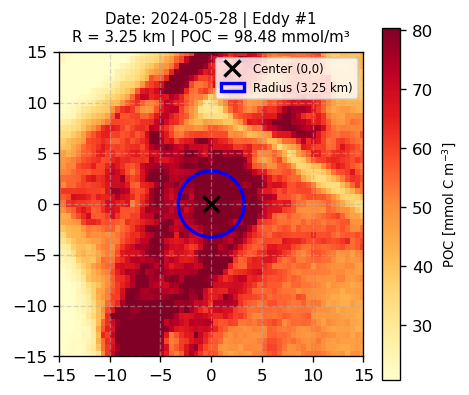

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


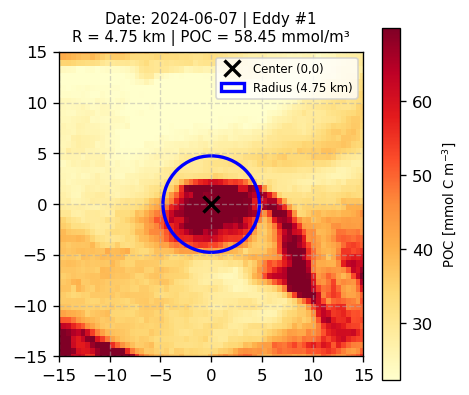

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


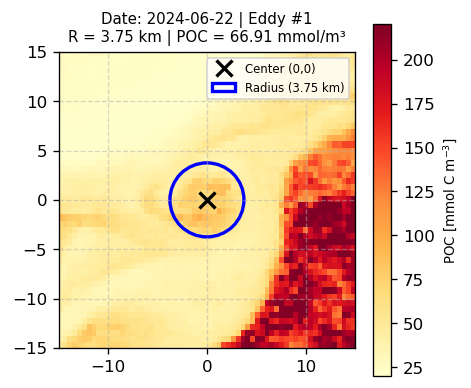

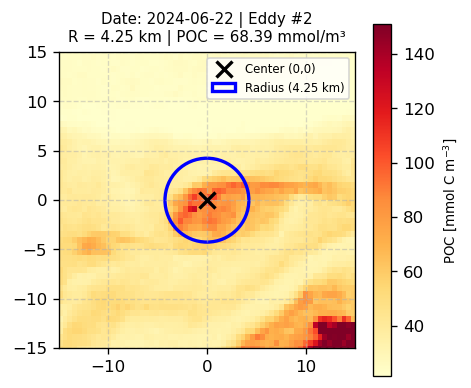

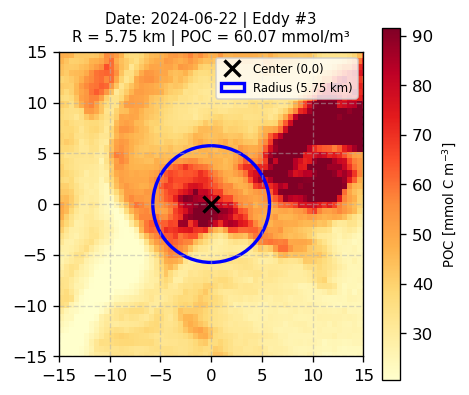

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:30: RuntimeWarning: Mean of empty slice
  c_peak = np.nanmean(poc_values[dist_km <= 1.0])
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:44: RuntimeWarning: Mean of empty slice
  np.nanmean(poc_values[bin_indices == i]) if np.any(bin_indices == i) else np.nan
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


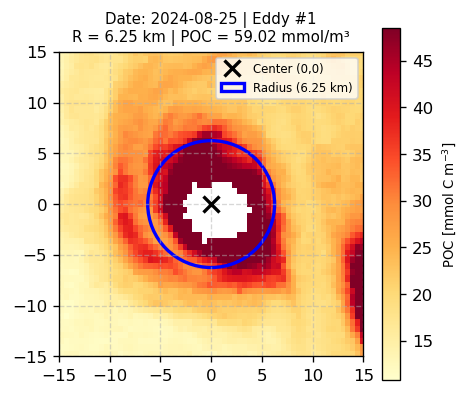

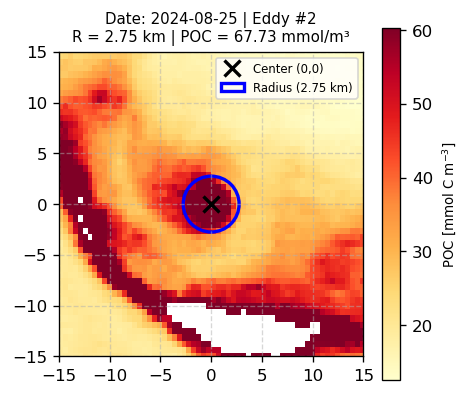

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


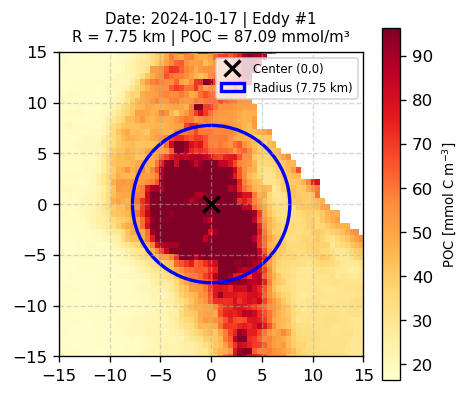

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:44: RuntimeWarning: Mean of empty slice
  np.nanmean(poc_values[bin_indices == i]) if np.any(bin_indices == i) else np.nan
/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


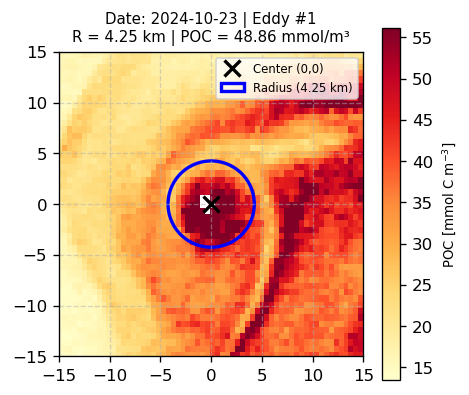

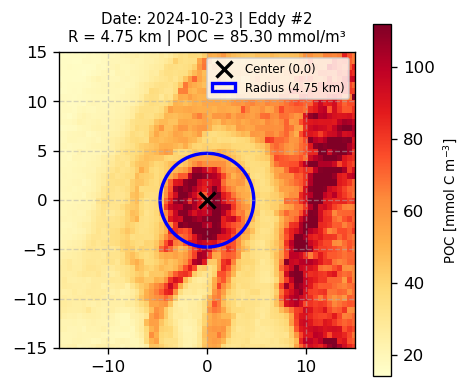

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


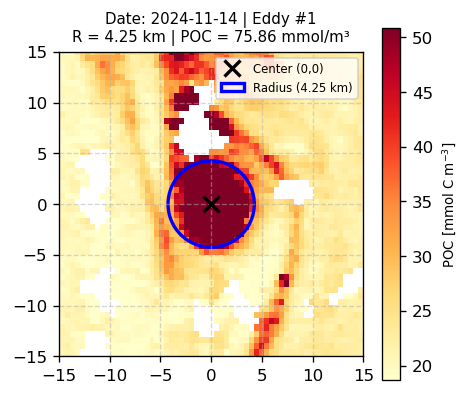

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


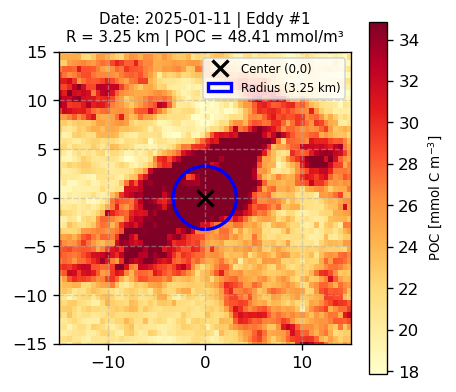

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


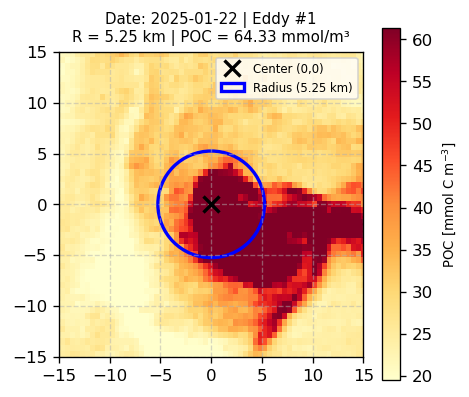

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


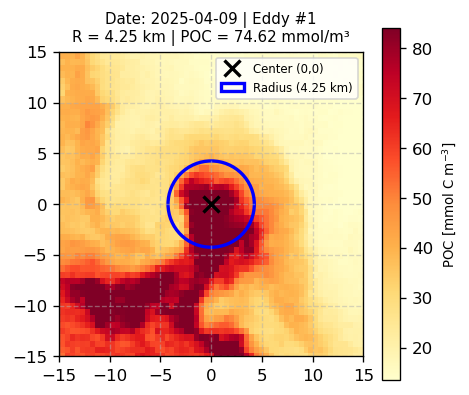

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


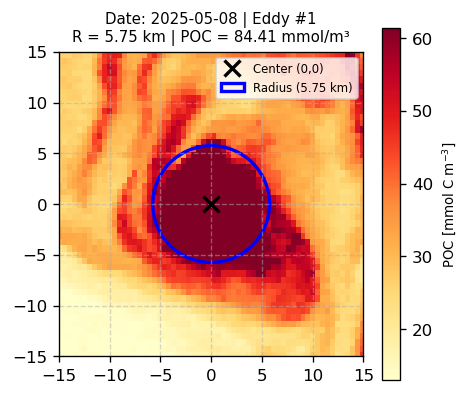

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


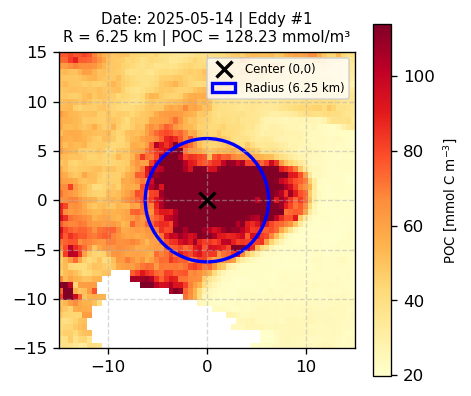

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


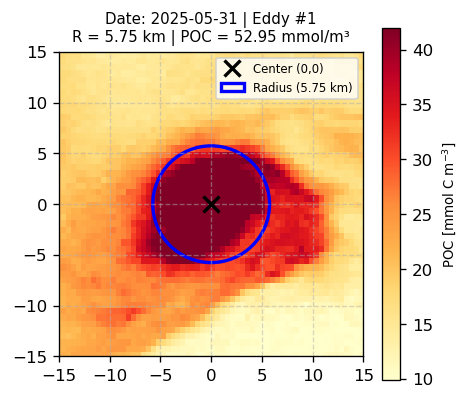

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


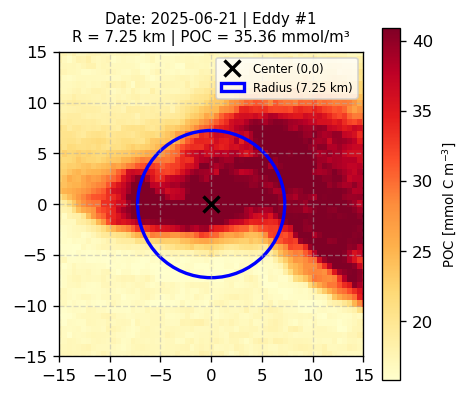

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


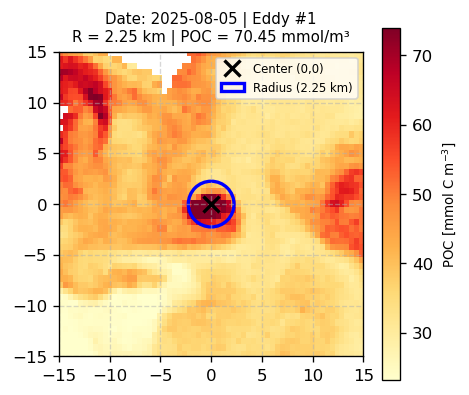

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


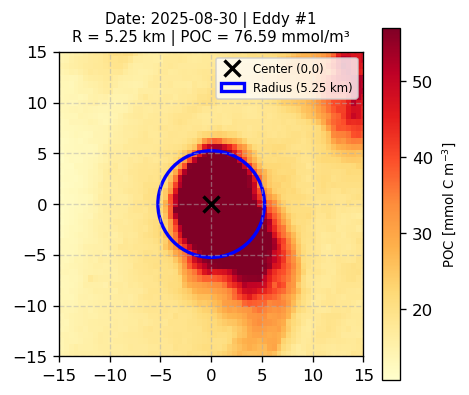

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_82978/657097530.py:125: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_val = np.trapz(integrand, r_m)               # [mmol C / m]


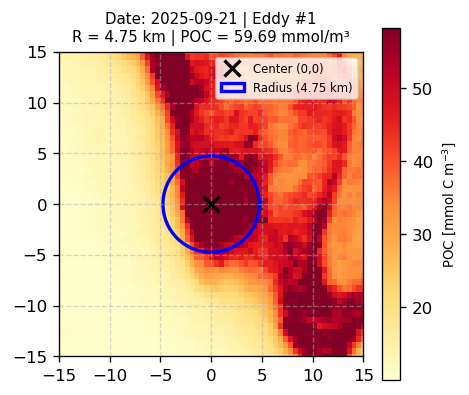

In [54]:
# main
MLD = 25  # mixed-layer depth

# read excel sheet
excel_path = "../count-submesoscale-eddies.xlsx"
olci_dir = "../olci_300m_downloads"
df = pd.read_excel(excel_path)
df.columns = ['Date', 'Count', 'Coord1', 'Coord2', 'Coord3'] + list(df.columns[5:])

eddy_summary = []

for idx, row in df.iterrows():
    date_dt = pd.to_datetime(row['Date'])
    
    if pd.isna(date_dt):
        continue
        
    date_str = date_dt.strftime('%Y-%m-%d')
    nc_file = os.path.join(olci_dir, f"OLCI_300m_CHL_{date_str}.nc")
    
    if not os.path.exists(nc_file):
        continue
        
    coords = [parse_coord(row['Coord1']), parse_coord(row['Coord2']), parse_coord(row['Coord3'])]
    coords = [c for c in coords if c is not None]
    
    if not coords:
        continue
        
    with xr.open_dataset(nc_file) as ds:
        chl = ds['CHL']
        for ed_idx, (lon_center, lat_center) in enumerate(coords, 1):
            delta = 0.25  # ~25 km crop window around core
            
            chl_crop = chl.sel(
                latitude=slice(lat_center - delta, lat_center + delta),
                longitude=slice(lon_center - delta, lon_center + delta)
            )
            
            if chl_crop.size == 0 or np.isnan(chl_crop.values).all():
                continue

            # 1. Convert CHL to POC
            poc_crop = chl_to_poc_mmol(chl_crop)

            # compute relative distance grid (dx, dy)
            lons = chl_crop.longitude.values
            lats = chl_crop.latitude.values
            dy = (lats - lat_center) * 111.0
            dx = (lons - lon_center) * 111.0 * np.cos(np.radians(lat_center))
            
            lon_2d, lat_2d = np.meshgrid(dx, dy)
            dist_km = np.sqrt(lon_2d**2 + lat_2d**2)

            # 2. Detect Eddy Radius
            detected_r_km, mean_core_poc, ring_centers, ring_poc_means = detect_eddy_radius_threshold(
                poc_values=np.squeeze(poc_crop.values), 
                dist_km=dist_km,
                threshold_pct=0.30,
                step_km=0.5
            )

            # 3. Compute POC Inventory
            inventory_GgC = compute_poc_inventory(
                radii_centers=ring_centers,
                ring_poc_means=ring_poc_means,
                detected_r_km=detected_r_km,
                mld_m=MLD
            )

            # 4. Compute background POC
            c_bg_eddy_lon = compute_line_background_at_eddy_lon(
                ds=ds,
                lon_center=lon_center,
                lat_center=lat_center,
                radius_km=detected_r_km,
                lat_min=36.0,
                lat_max=39.0
            )

            # Append
            eddy_summary.append({
                'Date': date_str,
                'Eddy_ID': ed_idx,
                'Lon': lon_center,
                'Lat': lat_center,
                'Radius_km': detected_r_km,
                'Core_POC_mmol_m3': mean_core_poc,
                'BG_EddyLon_mmol_m3': c_bg_eddy_lon,
                'Inventory_GgC': inventory_GgC
            })

            # 5. Plot Eddy
            plot_eddy_crop(
                poc_crop=poc_crop, dx=dx, dy=dy, 
                lon_center=lon_center, lat_center=lat_center, 
                date_str=date_str, ed_idx=ed_idx, 
                detected_r_km=detected_r_km, mean_core_poc=mean_core_poc, 
                plot_type='relative'
            )

# Output
df_eddy_stats = pd.DataFrame(eddy_summary)
ds_eddy_stats = df_eddy_stats.to_xarray()

#### Compare Satellite vs. In-Situ POC

Satellite POC estimates seem inflated compared to our in-situ measurements, so we will correct these values by scaling them using the ratio between our satellite POC and shipboard TSG measurements:

$$
\text{Ratio}_{\text{POC}} = \frac{\text{POC}_{\text{satellite}}}{\text{POC}_{\text{in situ}}}
$$

In [55]:
# first eddy is ours, let compare POC values
ratio_POC_Conc = ds_eddy_stats.isel(index=0)['Core_POC_mmol_m3'].values/C_bar_eddy
ratio_POC_Inv  = ds_eddy_stats.isel(index=0)['Inventory_GgC'].values/M_eddy_Gg

print('-- Values --')
print(f'POC Concentration: {ds_eddy_stats.isel(index=0)['Core_POC_mmol_m3'].values} vs {C_bar_eddy}')
print(f'POC Inventory: {ds_eddy_stats.isel(index=0)['Inventory_GgC'].values} vs {M_eddy_Gg}')

# there is a different of factor ~5, which we will use to compare eddies
print('')
print('-- Ratio --')
print(f'Ratio Concentration = {ratio_POC_Conc}')
print(f'Ratio Inventory = {ratio_POC_Inv}')

-- Values --
POC Concentration: 72.5132064819336 vs 17.17883393117603
POC Inventory: 2.2530436751259826 vs 0.40513777474268103

-- Ratio --
Ratio Concentration = 4.221078495341708
Ratio Inventory = 5.5611789756138625


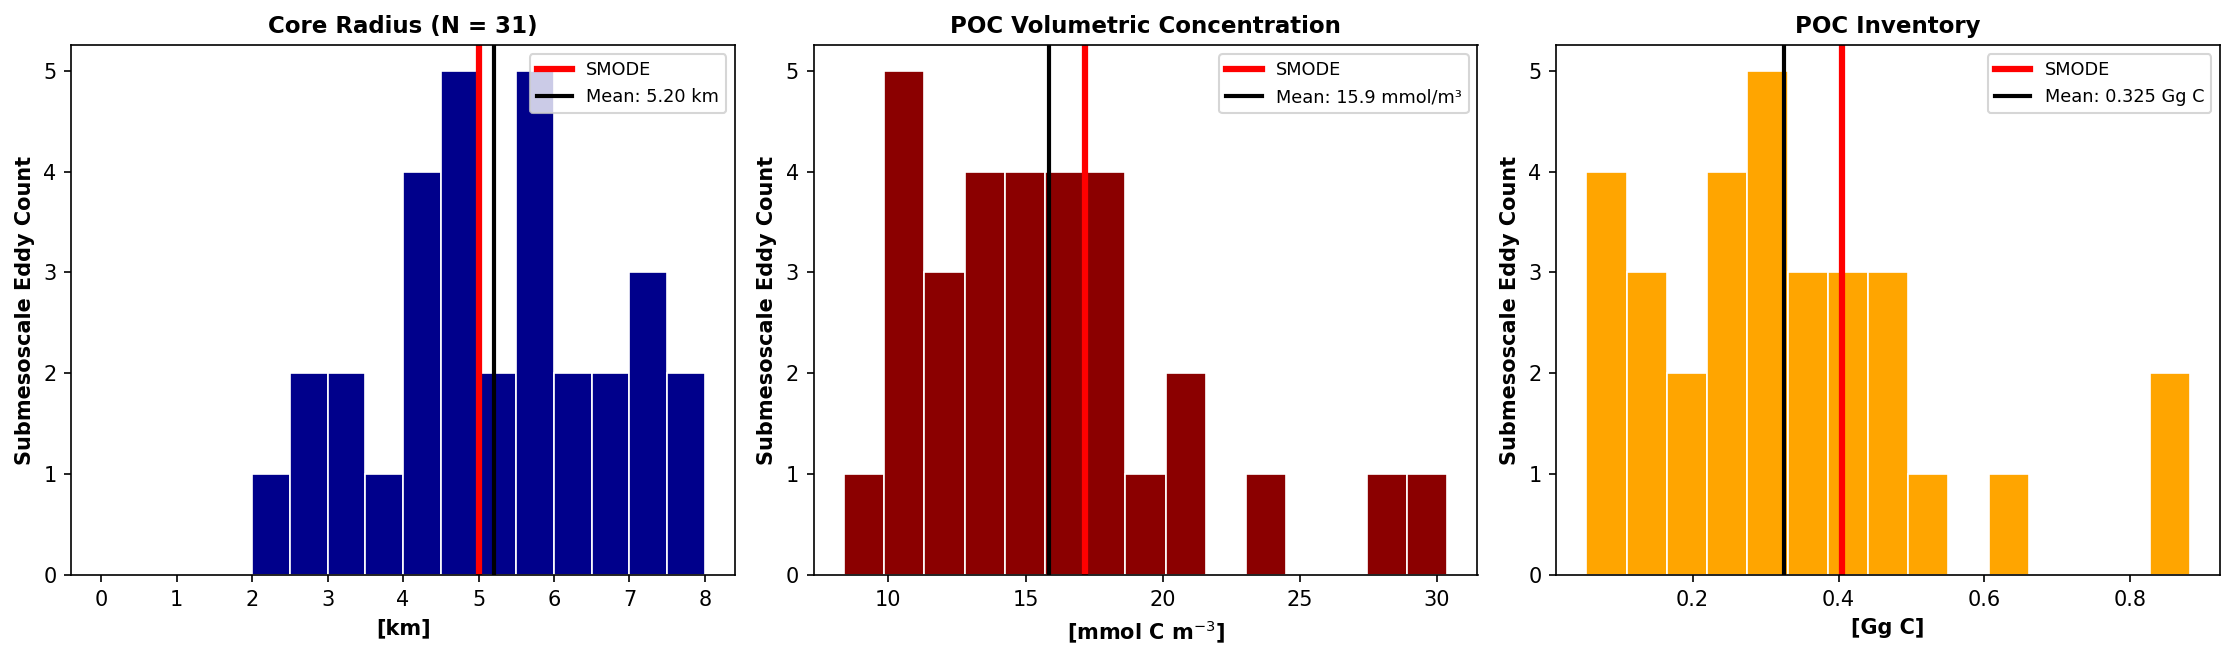

In [56]:
# compare our eddy with the average

clean_df = pd.DataFrame(df_eddy_stats).dropna(
    subset=['Radius_km', 'Core_POC_mmol_m3', 'Inventory_GgC']
)

# Apply the in-situ calibration scaling factor (Divide by 5)
clean_df['Core_POC_mmol_m3'] = clean_df['Core_POC_mmol_m3'] / ratio_POC_Conc
clean_df['Inventory_GgC'] = clean_df['Inventory_GgC'] / ratio_POC_Inv

# Statistics
stats = {
    'r_mean': clean_df['Radius_km'].mean(),
    'r_median': clean_df['Radius_km'].median(),
    'c_mean': clean_df['Core_POC_mmol_m3'].mean(),
    'c_median': clean_df['Core_POC_mmol_m3'].median(),
    'inv_mean': clean_df['Inventory_GgC'].mean(),
    'inv_median': clean_df['Inventory_GgC'].median()
}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)

# PANEL 1: RADII DISTRIBUTION
ax1.hist(
    clean_df['Radius_km'], 
    bins=np.arange(0, clean_df['Radius_km'].max() + 0.5, 0.5),
    color='darkblue', edgecolor='w', alpha=1, linewidth=0.8
)
ax1.axvline(R_eddy/1e3, color='r', linewidth=3, label='SMODE') # ***

ax1.axvline(stats['r_mean'], color='k', linestyle='-', lw=2, label=f"Mean: {stats['r_mean']:.2f} km")
ax1.set_xlabel(r'[km]', fontweight='bold', fontsize=10)
ax1.set_ylabel('Submesoscale Eddy Count', fontweight='bold', fontsize=10)
ax1.set_title(f'Core Radius (N = {len(clean_df)})', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right', fontsize=8.5)

# PANEL 2: VOLUMETRIC CONCENTRATION DISTRIBUTION
ax2.hist(
    clean_df['Core_POC_mmol_m3'], 
    bins=15,
    color='darkred', edgecolor='w', alpha=1, linewidth=0.8
)
ax2.axvline(C_bar_eddy, color='r', linewidth=3, label='SMODE') # ***

ax2.axvline(stats['c_mean'], color='k', linestyle='-', lw=2, label=f"Mean: {stats['c_mean']:.1f} mmol/m³")
ax2.set_xlabel(r'[mmol C m$^{-3}$]', fontweight='bold', fontsize=10)
ax2.set_ylabel('Submesoscale Eddy Count', fontweight='bold', fontsize=10)
ax2.set_title(r'POC Volumetric Concentration', fontsize=11, fontweight='bold')
ax2.legend(loc='upper right', fontsize=8.5)

# PANEL 3: POC INVENTORY (Gg C) DISTRIBUTION
ax3.hist(
    clean_df['Inventory_GgC'], 
    bins=15, 
    color='orange', edgecolor='w', alpha=1, linewidth=0.8
)
ax3.axvline(M_eddy_Gg, color='r', linewidth=3, label='SMODE') # ***
ax3.axvline(stats['inv_mean'], color='k', linestyle='-', lw=2, label=f"Mean: {stats['inv_mean']:.3f} Gg C")
ax3.set_xlabel(r'[Gg C]', fontweight='bold', fontsize=10)
ax3.set_ylabel('Submesoscale Eddy Count', fontweight='bold', fontsize=10)
ax3.set_title(r'POC Inventory', fontsize=11, fontweight='bold')
ax3.legend(loc='upper right', fontsize=8.5)


plt.tight_layout()
plt.show()

### Fractional occupation $\hat{f}$

In [57]:
def compute_f_hat_line124(ds, radius_km, lat_min=36.0, lat_max=39.0, line_lon=-124.0):
    
    # slice 124 W between 36°N and 39°N
    line_slice = ds['CHL'].sel(longitude=line_lon, method='nearest').sel(
        latitude=slice(lat_min, lat_max))
    
    # extract cloud-free (non-NaN) data points along Line 124
    vals = np.squeeze(line_slice.values)
    valid_mask = ~np.isnan(vals)
    cloud_free_pixels = np.sum(valid_mask)
    
    if cloud_free_pixels == 0:
        return 0.0  # Completely cloudy along Line 124
        
    # compute distance per grid point
    lats = line_slice['latitude'].values
    if len(lats) > 1:
        lat_step_km = np.abs(lats[1] - lats[0]) * 111.0
    else:
        lat_step_km = 0.3  # Default 300m pixel resolution
        
    # total cloud-free line length [km] (max ~333 km if 100% clear)
    cloud_free_length_km = cloud_free_pixels * lat_step_km
    
    # eddy diameter over cloud-free line length
    eddy_diameter_km = 2.0 * radius_km
    f_hat = eddy_diameter_km / cloud_free_length_km
    
    return float(min(f_hat, 1.0))


Mean f_hat across all eddies: 0.0398


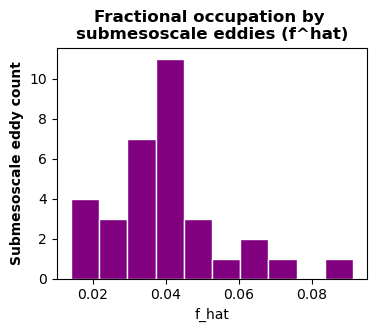

In [58]:
f_hat_list = []

# loop over each eddy
for idx, row in df_eddy_stats.iterrows():
    date_str = str(row['Date'])
    nc_file = os.path.join(olci_dir, f"OLCI_300m_CHL_{date_str}.nc")
    
    if os.path.exists(nc_file):
        with xr.open_dataset(nc_file) as ds:
            f_hat_val = compute_f_hat_line124(
                ds=ds,
                radius_km=row['Radius_km'],
                lat_min=36.0,
                lat_max=39.0,
                line_lon=-124.0
            )
    else:
        f_hat_val = 0.0
        
    f_hat_list.append(f_hat_val)

df_eddy_stats['f_hat'] = f_hat_list
ds_eddy_stats = df_eddy_stats.to_xarray()

print(f"Mean f_hat across all eddies: {df_eddy_stats['f_hat'].mean():.4f}")

# plot
ds_eddy_stats['f_hat'].plot.hist(color='purple', edgecolor='w', figsize=(4,3))
plt.title('Fractional occupation by \nsubmesoscale eddies (f^hat)',fontweight='bold')
plt.ylabel('Submesoscale eddy count',fontweight='bold')
plt.show();

## POC Eddy Flux

$$
F' = u_{\text{eddy}} \times \bar{C}' \times \hat{f}
$$

units: $mmol$ $C$ $m^{-2} s^{-1}$

In [59]:
# apply scaling factor
c_core_calibrated = ds_eddy_stats['Core_POC_mmol_m3'] / ratio_POC_Conc
c_bg_calibrated = ds_eddy_stats['BG_EddyLon_mmol_m3'] / ratio_POC_Conc

# 1. Compute Ensemble Mean Parameters
mean_C_core = c_core_calibrated.mean()
mean_C_bg = c_bg_calibrated.mean()
mean_C_prime = mean_C_core - mean_C_bg  # POC concentration Anomaly C' [mmol C / m3]
mean_f_hat = ds_eddy_stats['f_hat'].mean()   # Mean fractional line coverage f_hat

# 2. Calculate F' per second
# F' = u_eddy * C'_bar * f_hat [mmol C m^-2 s^-1]
F_prime_per_sec = u_eddy * mean_C_prime * mean_f_hat

# 3. Per day and Per year
seconds_per_day = 86400
seconds_per_year = 365.25 * seconds_per_day

F_prime_per_day = F_prime_per_sec * seconds_per_day   # [mmol C m^-2 day^-1]
F_prime_per_year = F_prime_per_sec * seconds_per_year # [mmol C m^-2 yr^-1]

# 4. Mass Conversion (mmol C -> g C -> mol C)
F_prime_gC_m2_yr = (F_prime_per_year * 12.011) / 1000.0 # [g C m^-2 yr^-1]
F_prime_molC_m2_yr = F_prime_per_year / 1000.0           # [mol C m^-2 yr^-1]

# Display Results
print("="*60)
print(" LATERAL SUBMESOSCALE EDDY POC FLUX (F') ")
print("="*60)
print(f"Inputs (N = {len(clean_df)}):")
print(f"  u_eddy (Advection Speed)          : {u_eddy:.2f} m/s")
print(f"  Mean C_core (Calibrated)          : {mean_C_core:.2f} mmol C / m³")
print(f"  Mean C_bg (Calibrated)            : {mean_C_bg:.2f} mmol C / m³")
print(f"  Mean C' (Anomaly)                 : {mean_C_prime:.2f} mmol C / m³")
print(f"  Mean f_hat (Fractional Coverage)  : {mean_f_hat:.4f}")
print("-" * 60)
print("Lateral Eddy Flux (F'):")
print(f"  F' (Instantaneous Flux)     : {F_prime_per_sec:.4f} mmol C m⁻² s⁻¹")
print(f"  F' (Daily Flux)             : {F_prime_per_day:.2f} mmol C m⁻² day⁻¹")
print(f"  F' (Annual Mass Flux)       : {F_prime_gC_m2_yr:.2f} g C m⁻² yr⁻¹")
print("-" * 60)
print("Annual POC Enrichment (comparison with Amos et al., 2019):")
line_124_dist_m = (39-36) * (111e3) # meters
print(f" {F_prime_gC_m2_yr * MLD * line_124_dist_m * mean_f_hat / 1e9:.2f} Gg C yr⁻¹")
print("="*60)


 LATERAL SUBMESOSCALE EDDY POC FLUX (F') 
Inputs (N = 31):
  u_eddy (Advection Speed)          : 0.05 m/s
  Mean C_core (Calibrated)          : 15.68 mmol C / m³
  Mean C_bg (Calibrated)            : 4.97 mmol C / m³
  Mean C' (Anomaly)                 : 10.71 mmol C / m³
  Mean f_hat (Fractional Coverage)  : 0.0398
------------------------------------------------------------
Lateral Eddy Flux (F'):
  F' (Instantaneous Flux)     : 0.0213 mmol C m⁻² s⁻¹
  F' (Daily Flux)             : 1838.93 mmol C m⁻² day⁻¹
  F' (Annual Mass Flux)       : 8067.40 g C m⁻² yr⁻¹
------------------------------------------------------------
Annual POC Enrichment (comparison with Amos et al., 2019):
 2.67 Gg C yr⁻¹
